### Phần code cho bài toán: Dự đoán chuyến bay bị trì hoãn trước khi chuyến bay xảy ra 

### 1. Khai báo các thư viện cần thiết 
1. pandas dùng để đọc file data, xử lý dữ liệu  
2. numpy dùng để xử lý, tính toán với mãng
3. matplotlib và seaborn dùng để trực quan dữ liệu bằng biểu đồ

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Tải dữ liệu gốc 

In [3]:
pd.set_option('display.max_columns', 200) 
df_begin = pd.read_csv('..\Dataset\DelayedFlights.csv')
df_begin 

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,0,2008,1,3,4,2003.0,1955,2211.0,2225,WN,335,N712SW,128.0,150.0,116.0,-14.0,8.0,IAD,TPA,810,4.0,8.0,0,N,0,NaN,NaN,NaN,NaN,NaN
1,1,2008,1,3,4,754.0,735,1002.0,1000,WN,3231,N772SW,128.0,145.0,113.0,2.0,19.0,IAD,TPA,810,5.0,10.0,0,N,0,NaN,NaN,NaN,NaN,NaN
2,2,2008,1,3,4,628.0,620,804.0,750,WN,448,N428WN,96.0,90.0,76.0,14.0,8.0,IND,BWI,515,3.0,17.0,0,N,0,NaN,NaN,NaN,NaN,NaN
3,4,2008,1,3,4,1829.0,1755,1959.0,1925,WN,3920,N464WN,90.0,90.0,77.0,34.0,34.0,IND,BWI,515,3.0,10.0,0,N,0,2.0,0.0,0.0,0.0,32.0
4,5,2008,1,3,4,1940.0,1915,2121.0,2110,WN,378,N726SW,101.0,115.0,87.0,11.0,25.0,IND,JAX,688,4.0,10.0,0,N,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936753,7009710,2008,12,13,6,1250.0,1220,1617.0,1552,DL,1621,N938DL,147.0,152.0,120.0,25.0,30.0,MSP,ATL,906,9.0,18.0,0,N,0,3.0,0.0,0.0,0.0,22.0
1936754,7009717,2008,12,13,6,657.0,600,904.0,749,DL,1631,N3743H,127.0,109.0,78.0,75.0,57.0,RIC,ATL,481,15.0,34.0,0,N,0,0.0,57.0,18.0,0.0,0.0
1936755,7009718,2008,12,13,6,1007.0,847,1149.0,1010,DL,1631,N909DA,162.0,143.0,122.0,99.0,80.0,ATL,IAH,689,8.0,32.0,0,N,0,1.0,0.0,19.0,0.0,79.0
1936756,7009726,2008,12,13,6,1251.0,1240,1446.0,1437,DL,1639,N646DL,115.0,117.0,89.0,9.0,11.0,IAD,ATL,533,13.0,13.0,0,N,0,NaN,NaN,NaN,NaN,NaN


### 3. EDA (Exploratory Data Analysis)
Mục tiêu của phần EDA là:
- Hiểu dataset gồm những cột nào
- Kiểm tra dữ liệu thiếu
- Kiểm tra dữ liệu bị lệch và outlier
- Tìm yếu tố liên quan đến việc chuyến bay bị hoãn
- Trực quan hóa dữ liệu cho bài toán - đưa ra kết luận
- Phát hiện cột vô ích hoặc gây data leakage
- Chuẩn bị dữ liệu cho bước preprocessing và train model

### 3.1 Thực hiện các bước lấy thông tin dữ liệu và kiểm tra dữ liệu

In [4]:
# 3.1.1 Kiểm tra kích thước và lấy thông tin các cột dữ liệu chính
print(f"Kích thước dữ liệu: {df_begin.shape}")
print('Các cột từ tập dữ liệu:')
df_begin.columns

Kích thước dữ liệu: (1936758, 30)
Các cột từ tập dữ liệu:


Index(['Unnamed: 0', 'Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime',
       'CRSDepTime', 'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum',
       'TailNum', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay',
       'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='str')

Ý nghĩa của các cột trong tập dữ liệu: 
- Unnamed: cột dữ liệu dư được thư viện pandas lưu lại
- Year: Năm thông kê của các chuyến bay
- Month: Tháng trong năm
- DayofMonth: Ngày trong tháng
- DayofWeek: Ngày trong tuần 
- DepTime: Thời gian khởi hành thực tế
- CRSDepTime: Thời gian khởi hành dự kiến
- ArrTime: Thời gian hạ cánh thực tế
- CRSArrTime: Thời gian hạ cánh dự kiến
- UniqueCarrier: Hãng bay độc quyền.
- FlightNum: Số hiệu chuyến bay
- TailNum: Biển số của máy bay
- ActualElapsedTime: Thời gian hoàn thành thực tế của chuyến bay đó
- CRSElapsedTime: Thời gian hoàn thành dự kiến của chuyến bay đó
- AirTime: Thời gian ở trên không
- ArrDelay: Thời gian delay của chuyến bay lúc hạ cánh
- DepDelay: Thời gian delay của chuyến bay lúc khởi hành
- Origin: Sân bay đi
- Dest: Sân bay đến
- Distance: Khoảng cách giữa hai sân bay
- TaxiIn với TaxiOut: Lưu thời gian từ cổng ra đường bay
- Cancelled: Đánh dấu có hủy chuyến hay không (0 hoặc 1)
- CancellationCode: Mã số bị Cancelled
- Diverted: Đánh dấu có bị chuyển hướng hay không (0 hoặc 1)
- Và một số đặc trung lưu lại thời gian bị delay do hãng, thời tiết,... 

In [5]:
# 3.1.2 Kiểm tra kích thước và thông tin tổng quát
df_begin.info()

<class 'pandas.DataFrame'>
RangeIndex: 1936758 entries, 0 to 1936757
Data columns (total 30 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Unnamed: 0         int64  
 1   Year               int64  
 2   Month              int64  
 3   DayofMonth         int64  
 4   DayOfWeek          int64  
 5   DepTime            float64
 6   CRSDepTime         int64  
 7   ArrTime            float64
 8   CRSArrTime         int64  
 9   UniqueCarrier      str    
 10  FlightNum          int64  
 11  TailNum            str    
 12  ActualElapsedTime  float64
 13  CRSElapsedTime     float64
 14  AirTime            float64
 15  ArrDelay           float64
 16  DepDelay           float64
 17  Origin             str    
 18  Dest               str    
 19  Distance           int64  
 20  TaxiIn             float64
 21  TaxiOut            float64
 22  Cancelled          int64  
 23  CancellationCode   str    
 24  Diverted           int64  
 25  CarrierDelay       float64
 2

In [5]:
# 3.1.3 Thống kê mô tả nhanh cho dữ liệu
df_begin.describe()

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,FlightNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Distance,TaxiIn,TaxiOut,Cancelled,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,1.936758e+06,1936758.0,1.936758e+06,1.936758e+06,1.936758e+06,1.936758e+06,1.936758e+06,1.929648e+06,1.936758e+06,1.936758e+06,1.928371e+06,1.936560e+06,1.928371e+06,1.928371e+06,1.936758e+06,1.936758e+06,1.929648e+06,1.936303e+06,1.936758e+06,1.936758e+06,1.247488e+06,1.247488e+06,1.247488e+06,1.247488e+06,1.247488e+06
mean,3.341651e+06,2008.0,6.111106e+00,1.575347e+01,3.984827e+00,1.518534e+03,1.467473e+03,1.610141e+03,1.634225e+03,2.184263e+03,1.333059e+02,1.343027e+02,1.082771e+02,4.219988e+01,4.318518e+01,7.656862e+02,6.812975e+00,1.823220e+01,3.268348e-04,4.003598e-03,1.917940e+01,3.703571e+00,1.502164e+01,9.013714e-02,2.529647e+01
std,2.066065e+06,0.0,3.482546e+00,8.776272e+00,1.995966e+00,4.504853e+02,4.247668e+02,5.481781e+02,4.646347e+02,1.944702e+03,7.206007e+01,7.134144e+01,6.864261e+01,5.678472e+01,5.340250e+01,5.744797e+02,5.273595e+00,1.433853e+01,1.807562e-02,6.314722e-02,4.354621e+01,2.149290e+01,3.383305e+01,2.022714e+00,4.205486e+01
min,0.000000e+00,2008.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.400000e+01,-2.500000e+01,0.000000e+00,-1.090000e+02,6.000000e+00,1.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.517452e+06,2008.0,3.000000e+00,8.000000e+00,2.000000e+00,1.203000e+03,1.135000e+03,1.316000e+03,1.325000e+03,6.100000e+02,8.000000e+01,8.200000e+01,5.800000e+01,9.000000e+00,1.200000e+01,3.380000e+02,4.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.242558e+06,2008.0,6.000000e+00,1.600000e+01,4.000000e+00,1.545000e+03,1.510000e+03,1.715000e+03,1.705000e+03,1.543000e+03,1.160000e+02,1.160000e+02,9.000000e+01,2.400000e+01,2.400000e+01,6.060000e+02,6.000000e+00,1.400000e+01,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,8.000000e+00
75%,4.972467e+06,2008.0,9.000000e+00,2.300000e+01,6.000000e+00,1.900000e+03,1.815000e+03,2.030000e+03,2.014000e+03,3.422000e+03,1.650000e+02,1.650000e+02,1.370000e+02,5.600000e+01,5.300000e+01,9.980000e+02,8.000000e+00,2.100000e+01,0.000000e+00,0.000000e+00,2.100000e+01,0.000000e+00,1.500000e+01,0.000000e+00,3.300000e+01
max,7.009727e+06,2008.0,1.200000e+01,3.100000e+01,7.000000e+00,2.400000e+03,2.359000e+03,2.400000e+03,2.400000e+03,9.742000e+03,1.114000e+03,6.600000e+02,1.091000e+03,2.461000e+03,2.467000e+03,4.962000e+03,2.400000e+02,4.220000e+02,1.000000e+00,1.000000e+00,2.436000e+03,1.352000e+03,1.357000e+03,3.920000e+02,1.316000e+03


In [6]:
# 3.1.4 Kiểm tra dữ liệu bị thiếu 
missing_data = df_begin.isna().sum().sort_values(ascending=False)
print("Số lượng dữ liệu thiếu trên từng cột:")
print(missing_data[missing_data > 0])

Số lượng dữ liệu thiếu trên từng cột:
NASDelay             689270
CarrierDelay         689270
LateAircraftDelay    689270
SecurityDelay        689270
WeatherDelay         689270
ActualElapsedTime      8387
AirTime                8387
ArrDelay               8387
TaxiIn                 7110
ArrTime                7110
TaxiOut                 455
CRSElapsedTime          198
TailNum                   5
dtype: int64


In [7]:
# 3.1.5 Kiểm tra dữ liệu trùng lặp
int(df_begin.duplicated().sum())

0

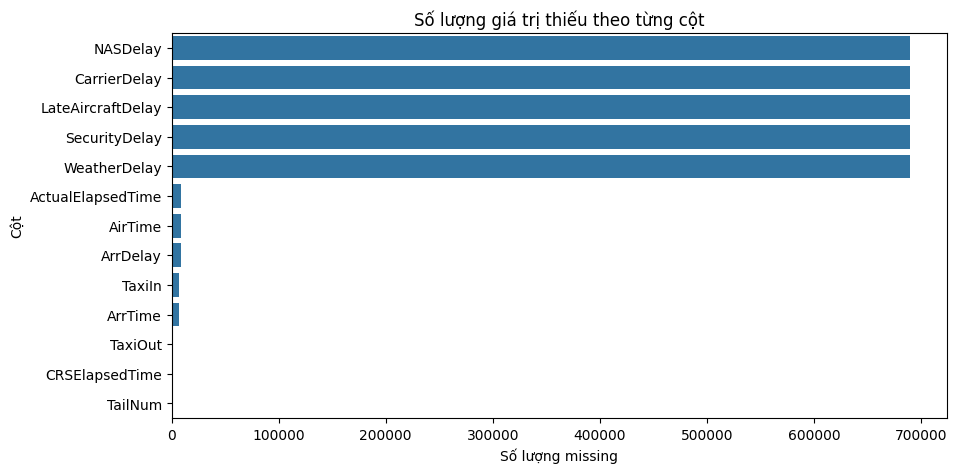

In [8]:
# 3.1.6 Trực quan hóa dữ liệu thiếu bằng biểu đồ cột
missing = df_begin.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(10,5))
sns.barplot(x=missing.values, y=missing.index)
plt.title("Số lượng giá trị thiếu theo từng cột")
plt.xlabel("Số lượng missing")
plt.ylabel("Cột")
plt.show()

=> Từ biểu đồ ta thấy, các giá trị null chủ yếu là ở thông tin về thời gian của các nguyên nhân - do các chuyến bay đó ko bị delay hoặc không ghi nhận được thông tin.

### 3.2 Trực quan tỉ lệ chuyến bay bị hủy - không bị hủy và bị chuyển hướng và không bị chuyển hướng 

Tỉ lệ những chuyến bay bị hủy và không bị hủy: Cancelled
0    0.999673
1    0.000327
Name: proportion, dtype: float64


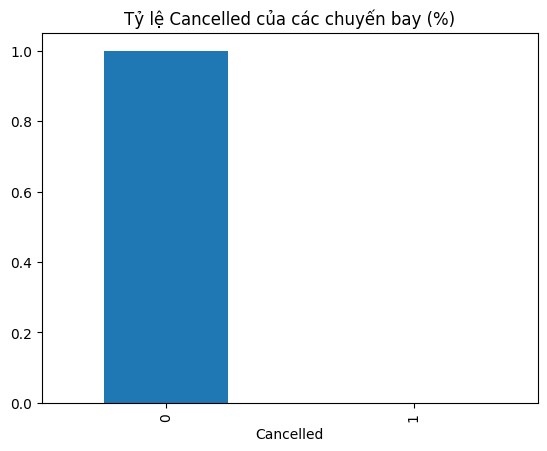

In [9]:
# 3.2.1 Trực quan tỉ lệ giữa chuyến bay bị hủy và không bị hủy
print('Tỉ lệ những chuyến bay bị hủy và không bị hủy:', df_begin['Cancelled'].value_counts(normalize=True))
df_begin['Cancelled'].value_counts(normalize=True).plot(kind='bar')
plt.title('Tỷ lệ Cancelled của các chuyến bay (%)')
plt.show()


Tỉ lệ những chuyến bay bị chuyển hướng và không bị chuyển hướng: Diverted
0    0.995996
1    0.004004
Name: proportion, dtype: float64


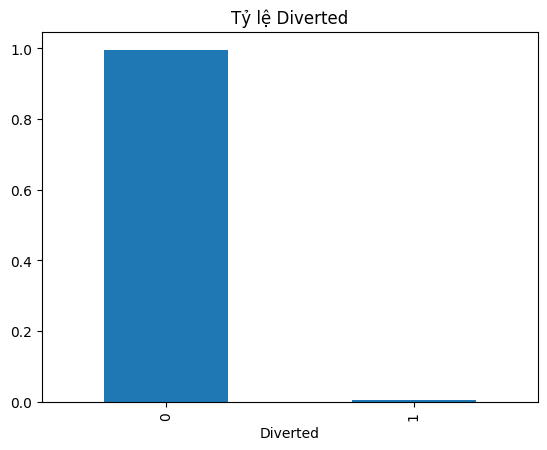

In [10]:
# 3.2.2 Trực quan giữa những chuyến bay bị chuyển hướng và không bị chuyển hưởng
print('Tỉ lệ những chuyến bay bị chuyển hướng và không bị chuyển hướng:', df_begin['Diverted'].value_counts(normalize=True))
df_begin['Diverted'].value_counts(normalize=True).plot(kind='bar')
plt.title('Tỷ lệ Diverted')
plt.show()

Với bài toán trên, ta chỉ giữ lại những chuyến bay có thông tin đúng theo bảng - nghĩa là nó không bị hủy hoặc chuyển hướng vì những chuyến bay bị hủy hoặc chuyển hướng, có thể nó sẽ không đi đến sân bay gốc đúng như dữ liệu tải hoặc là sẽ bị null ở giá trị như deptime hoặc arrtime. 

In [11]:
# 3.2.3 Chỉ giữ những chuyến bay không bị hủy và không bị chuyển hướng
df_filter = df_begin[(df_begin['Diverted'] == 0) & (df_begin['Cancelled'] == 0)]

In [12]:
# 3.2.4 Kiểm tra lại kích thước sau khi lọc
print(f"Kích thước dữ liệu: {df_filter.shape}")

Kích thước dữ liệu: (1928371, 30)


In [13]:
# 3.2.5 Kiểm tra dữ liệu bị thiếu sau khi lọc
missing_data = df_filter.isna().sum().sort_values(ascending=False)
print("Số lượng dữ liệu thiếu trên từng cột:")
print(missing_data[missing_data > 0])

Số lượng dữ liệu thiếu trên từng cột:
NASDelay             680883
CarrierDelay         680883
LateAircraftDelay    680883
SecurityDelay        680883
WeatherDelay         680883
TailNum                   3
dtype: int64


*Lưu ý: Chưa xử lý null, vì đây sẽ là dữ liệu trên chỉ gồm thời gian nguyên nhân bị delay và tailnum - Đây là những dữ liệu leakage và không có ý nghĩa cho bài toán nên không cần xử lý, tý sẽ được loại bỏ

In [14]:
# 3.2.6 Kiểm tra dữ liệu trùng lặp
int(df_filter.duplicated().sum())

0

### 3.3 Trực quan các nguyên nhân bị delay của các chuyến bay

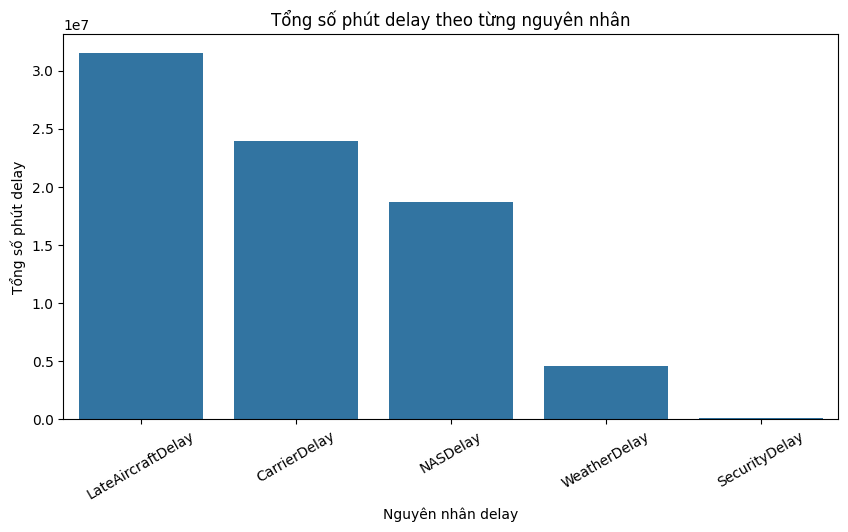

In [15]:
# 3.3.1 Trực quan nguyên nhân bằng biểu đồ cột
delay_cause_cols = [
    'CarrierDelay', 'WeatherDelay', 'NASDelay',
    'SecurityDelay', 'LateAircraftDelay'
]

# Chỉ xét các cột nguyên nhân delay có tồn tại trong dataset
existing_delay_cols = [col for col in delay_cause_cols if col in df_filter.columns]

# Tính tổng số phút delay theo từng nguyên nhân
delay_cause_sum = df_filter[existing_delay_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=delay_cause_sum.index, y=delay_cause_sum.values)
plt.title('Tổng số phút delay theo từng nguyên nhân')
plt.xlabel('Nguyên nhân delay')
plt.ylabel('Tổng số phút delay')
plt.xticks(rotation=30)
plt.show()

=> Từ biểu đồ, ta thấy được nguyên nhân delay phổ biến sẽ là do delay do chuyến bay đến trễ từ chuyến trước (LateAircraftDelay) và nguyên nhân ảnh hưởng ít nhất là delay do các vấn đề an ninh hàng không (SecurityDelay)

### 3.4 Trực quan phân phối khoảng cách di chuyển của mỗi chuyến bay và mối quan hệ với sự delay 

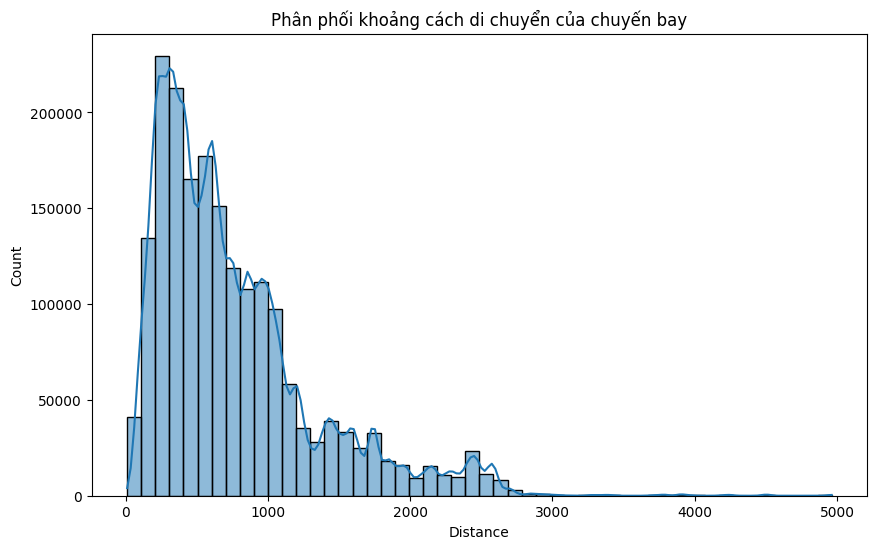

In [16]:
# 3.4.1 Trực quan phân phối số chuyến bay ứng với khoảng cách di chuyển của từng chuyến 
plt.figure(figsize=(10,6))
sns.histplot(df_filter['Distance'], bins=50, kde=True)
plt.title('Phân phối khoảng cách di chuyển của chuyến bay')
plt.xlabel('Distance')
plt.ylabel('Count')
plt.show()

=> Từ biểu đồ, các chuyến bay hầu hết có khoảng cách di chuyển từ 1000 km đổ lại nhưng có một số chuyến bay lại di chuyển rất xa lên tới 3000, 4000 và cao nhất là 5000 km.

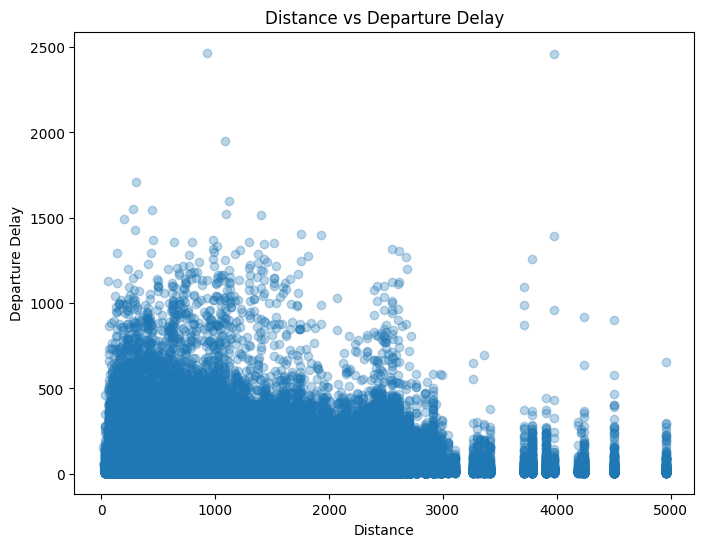

In [17]:
# 3.4.2 Trực quan sự tác động của distance đối với sự delay lúc khởi hành
plt.figure(figsize=(8,6))

plt.scatter(df_filter['Distance'], df_filter['DepDelay'], alpha=0.3)

plt.xlabel("Distance")
plt.ylabel("Departure Delay")
plt.title("Distance vs Departure Delay")

plt.show()

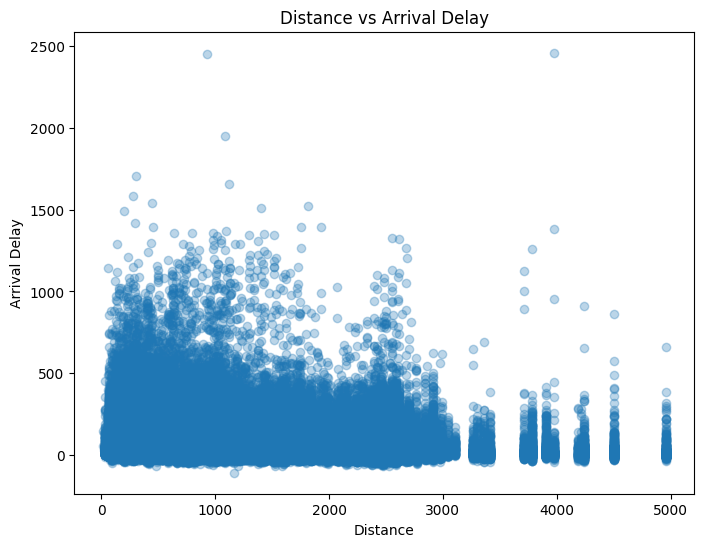

In [18]:
# 3.4.3 Trực quan ảnh hưởng của distance đối với sự delay lúc hạ cánh
plt.figure(figsize=(8,6))

plt.scatter(df_filter['Distance'], df_filter['ArrDelay'], alpha=0.3)

plt.xlabel("Distance")
plt.ylabel("Arrival Delay")
plt.title("Distance vs Arrival Delay")

plt.show()

In [19]:
# 3.4.4 Lấy correlation Matrix (ma trận tương quan) giữa distance với depdelay và arrdelay
df_filter[['Distance', 'DepDelay', 'ArrDelay']].corr()

,Distance,DepDelay,ArrDelay
Distance,1.000000,-0.007850,-0.029853
DepDelay,-0.007850,1.000000,0.952927
ArrDelay,-0.029853,0.952927,1.000000


=> Từ các biểu đồ và ma trận tương quan ta thấy distance có quan hệ phi tuyến với depdelay, arrdelay

### 3.5 Trực quan độ trễ lúc khởi hành (DepDelay) và độ trễ lúc hạ cánh (ArrDelay)

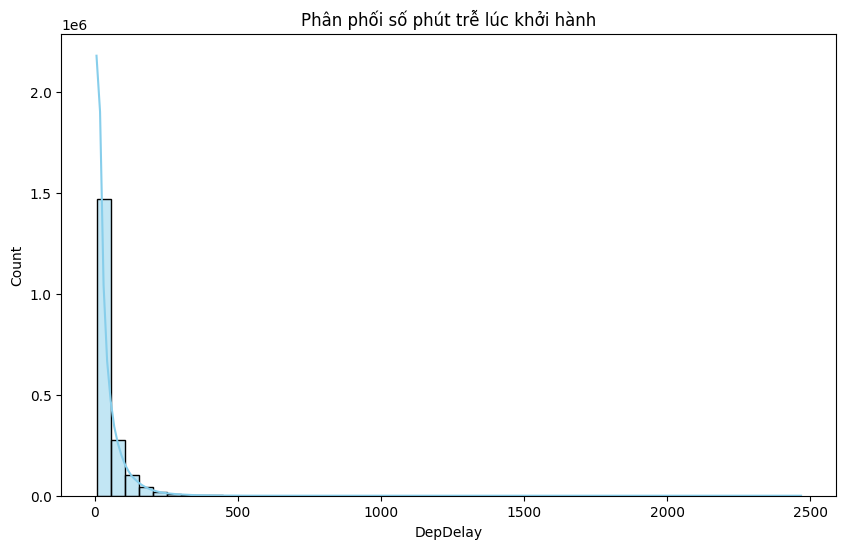

In [20]:
# 3.5.1 Vẽ Histogram cho ArrDelay
plt.figure(figsize=(10, 6))
sns.histplot(df_filter['DepDelay'], bins=50, kde=True, color='skyblue')
plt.title('Phân phối số phút trễ lúc khởi hành')
plt.show()

=> Ta thấy hầu như thời gian depdelay sẽ dưới 500 phút, nhưng sẽ có 1 ít chuyến delay hơn 500 phút và cao nhất là gần 2500 phút - có thể được xem là outilier nhưng ta sẽ không xử lý vì ta sẽ sử dụng feature này để tạo label cho bài toán classification nên không ảnh hưởng đến huấn luyện mô hình.

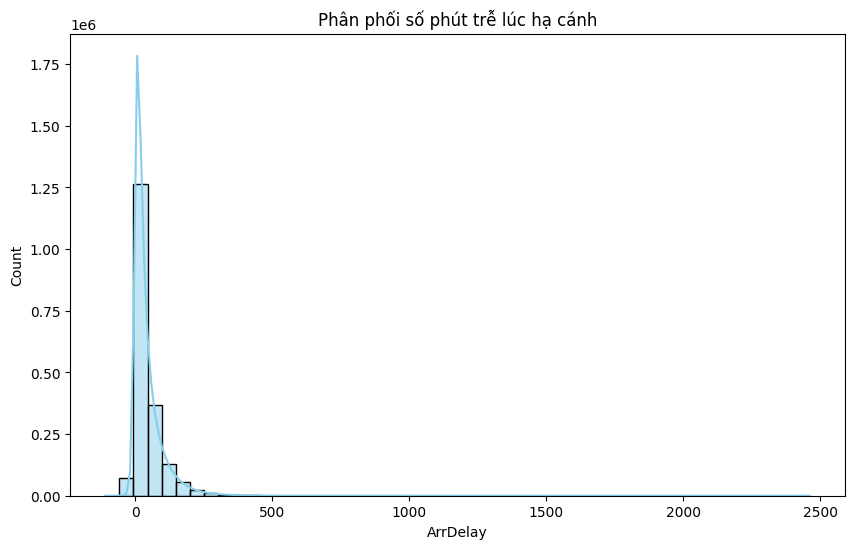

In [21]:
# 3.5.2 Vẽ Histogram cho ArrDelay
plt.figure(figsize=(10, 6))
sns.histplot(df_filter['ArrDelay'], bins=50, kde=True, color='skyblue')
plt.title('Phân phối số phút trễ lúc hạ cánh')
plt.show()

=> Ta thấy hầu như thời gian arrdelay sẽ dưới 500 phút và một số dưới 0 cho thấy chuyến bay đến sớm hơn giờ dự kiến, nhưng sẽ có 1 ít chuyến delay hơn 500 phút và cao nhất là gần 2500 phút - có thể được xem là outilier nhưng ta sẽ không xử lý vì ta sẽ sử dụng feature này để tạo label cho bài toán classification nên không ảnh hưởng đến huấn luyện mô hình.

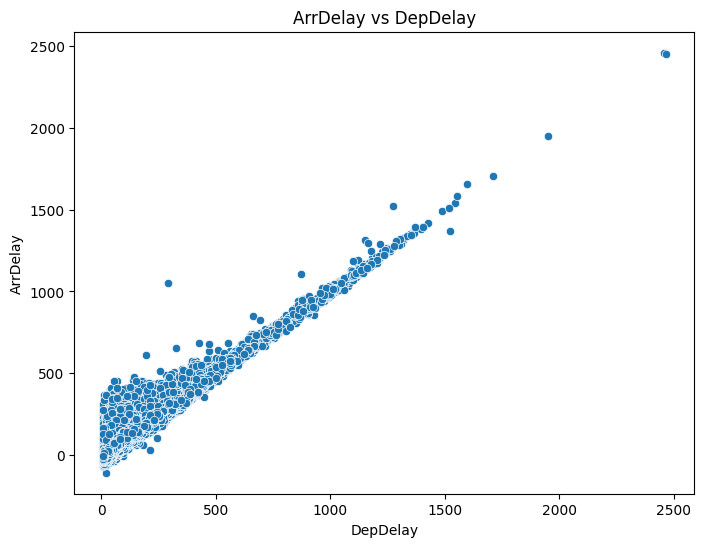

In [22]:
#Trực quan mối quan hệ giữa DepDelay với ArrDelay
plt.figure(figsize=(8,6))
sns.scatterplot(x = df_filter['DepDelay'], y= df_filter['ArrDelay'])
plt.title('ArrDelay vs DepDelay')
plt.xlabel('DepDelay')
plt.ylabel('ArrDelay')
plt.show()

In [23]:
# 3.5.4 Lấy ma trận tương quan giữa arrdeylay và depdelay
df_filter[['DepDelay','ArrDelay']].corr()

,DepDelay,ArrDelay
DepDelay,1.000000,0.952927
ArrDelay,0.952927,1.000000


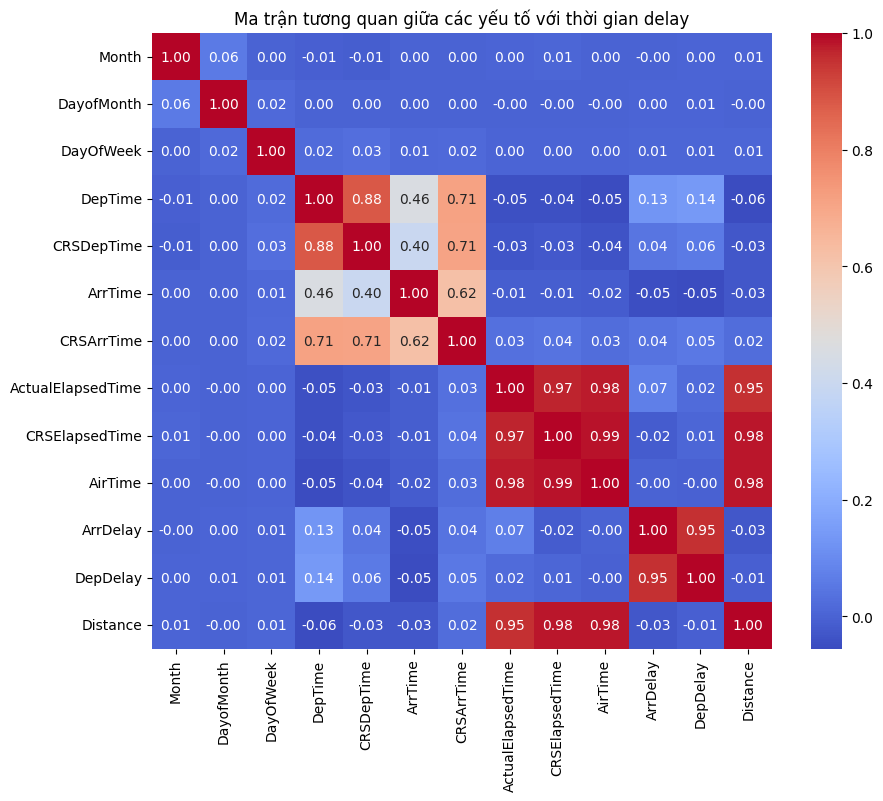

In [24]:
plt.figure(figsize=(10, 8))
corr_cols = ['Month', 'DayofMonth', 'DayOfWeek', 'DepTime',
       'CRSDepTime', 'ArrTime', 'CRSArrTime', 'ActualElapsedTime', 'CRSElapsedTime', 
       'AirTime', 'ArrDelay',
       'DepDelay', 'Distance']
corr_cols = [c for c in corr_cols if c in df_filter.columns]
corr_matrix = df_filter[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các yếu tố với thời gian delay')
plt.show()

=> Từ biểu đồ và ma trận tương quan ta thấy depdelay và arrdelay có mối quan hệ tuyến tính với nhau - Nếu DepDelay lớn cũng sẽ kéo theo Arrdelay.

*Lưu ý: Đó chỉ là quy luật kéo theo, không thể đúng hết vì sẽ có một số chuyến bay không bị delay lúc khởi hành những vẫn bị delay lúc hạ cánh do các nguyên nhân delay và ngược lại.

### 4. Chuẩn bị dữ liệu cho huấn luyện mô hình.

*Lưu ý: Bài toán chỉ gồm dữ liệu thống kê, mục tiêu là sử dụng dữ liệu phục vụ cho bài toán phân loại nên ta sẽ tạo thêm label dựa trên hai feature là DepDelay và ArrDelay.

### 4.1 Tạo label cho bài toán dự đoán delay của mỗi chuyến bay

Hầu hết các chuyến bay được nhận định là delay nếu thời gian khởi hành hoặc hạ cánh trễ hơn thời gian dự kiến là 15 phút - theo đó ta sẽ lấy ngưỡng tạo target/label là 15.

In [25]:
# 4.1.1 Tạo label cho bài toán dự đoán delay lúc khởi hành
df_filter['IsDelayed'] = ((df_filter['DepDelay'] > 15) | (df_filter['ArrDelay'] > 15)).astype(int)
df_filter['IsDelayed'].value_counts()

IsDelayed
1    1409931
0     518440
Name: count, dtype: int64

*Lưu ý: Mục tiêu là dự đoán những chuyến bay có bị delay không trước khi chuyến bay xảy ra nên ta sẽ loại bỏ những dữ liệu có thể gây ra leakage là dữ liệu sẽ làm cho model học trước kết quả sẽ làm model học sai và loại bỏ những dữ liệu không cần thiết tránh cho model học thông tin nhiễu.

### 4.2 Xử lý dữ liệu leakage , dữ liệu không cần thiết cho huấn luyện mô hình. 

In [26]:
# 4.2.1 Lấy tất cả các cột từ dữ liệu bao gồm cả những dữ liệu được lưu từ fearture Engineering
df_filter.columns

Index(['Unnamed: 0', 'Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime',
       'CRSDepTime', 'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum',
       'TailNum', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay',
       'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
       'IsDelayed'],
      dtype='str')

*Từ những cột dữ liệu ta sẽ loại bỏ những dữ liệu không cần thiết bao gồm Unnamed, Year, FlightNum, TailNum, Cancelled, CancellationCode, Diverted.

*Ta cũng sẽ loại bỏ các cột gây leakage. Vì ta sẽ dự đoán trước khi chuyến bay xảy ra nên ta sẽ loại bỏ các cột gồm Deptime, ArrTime, ActualElapsedTime, AirTime, ArrDelay, DepDelay, TaxiIn, TaxiOut, 'CarrierDelay','WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'.

In [27]:
# 4.2.2 Giữ lại các cột cần thiết và tạo ra bộ dữ liệu sạch
keep_cols = ['Month', 'DayofMonth', 'DayOfWeek','CRSDepTime', 
             'CRSArrTime', 'UniqueCarrier', 'CRSElapsedTime',
             'Origin', 'Dest', 'Distance', 'IsDelayed']
df_clean = df_filter[keep_cols].copy()
df_clean 

,Month,DayofMonth,DayOfWeek,CRSDepTime,CRSArrTime,UniqueCarrier,CRSElapsedTime,Origin,Dest,Distance,IsDelayed
0,1,3,4,1955,2225,WN,150.0,IAD,TPA,810,0
1,1,3,4,735,1000,WN,145.0,IAD,TPA,810,1
2,1,3,4,620,750,WN,90.0,IND,BWI,515,0
3,1,3,4,1755,1925,WN,90.0,IND,BWI,515,1
4,1,3,4,1915,2110,WN,115.0,IND,JAX,688,1
...,...,...,...,...,...,...,...,...,...,...,...
1936753,12,13,6,1220,1552,DL,152.0,MSP,ATL,906,1
1936754,12,13,6,600,749,DL,109.0,RIC,ATL,481,1
1936755,12,13,6,847,1010,DL,143.0,ATL,IAH,689,1
1936756,12,13,6,1240,1437,DL,117.0,IAD,ATL,533,0


### 4.3 Kiểm tra lại thông tin dữ liệu, xử lý null, trùng lặp - duplicated (nếu có)

In [28]:
# 4.3.1 Kiểm tra kích thước và lấy thống tin dữ liệu sau xử lý
print(f"Kích thước dữ liệu sau xử lý: {df_clean.shape}")
df_clean.info()


Kích thước dữ liệu sau xử lý: (1928371, 11)
<class 'pandas.DataFrame'>
Index: 1928371 entries, 0 to 1936757
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Month           int64  
 1   DayofMonth      int64  
 2   DayOfWeek       int64  
 3   CRSDepTime      int64  
 4   CRSArrTime      int64  
 5   UniqueCarrier   str    
 6   CRSElapsedTime  float64
 7   Origin          str    
 8   Dest            str    
 9   Distance        int64  
 10  IsDelayed       int64  
dtypes: float64(1), int64(7), str(3)
memory usage: 191.9 MB


In [25]:
# 4.3.2 Lấy thông tin thống kê
df_clean.describe()

,Month,DayofMonth,DayOfWeek,CRSDepTime,CRSArrTime,CRSElapsedTime,Distance,IsDelayed
count,1.928371e+06,1.928371e+06,1.928371e+06,1.928371e+06,1.928371e+06,1.928371e+06,1.928371e+06,1.928371e+06
mean,6.107855e+00,1.575206e+01,3.984999e+00,1.467718e+03,1.634196e+03,1.341977e+02,7.649486e+02,7.311513e-01
std,3.480753e+00,8.776566e+00,1.996050e+00,4.247281e+02,4.646284e+02,7.123339e+01,5.738858e+02,4.433612e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-2.100000e+01,1.100000e+01,0.000000e+00
25%,3.000000e+00,8.000000e+00,2.000000e+00,1.135000e+03,1.325000e+03,8.200000e+01,3.380000e+02,0.000000e+00
50%,6.000000e+00,1.600000e+01,4.000000e+00,1.510000e+03,1.705000e+03,1.160000e+02,6.060000e+02,1.000000e+00
75%,9.000000e+00,2.300000e+01,6.000000e+00,1.815000e+03,2.014000e+03,1.650000e+02,9.970000e+02,1.000000e+00
max,1.200000e+01,3.100000e+01,7.000000e+00,2.359000e+03,2.359000e+03,6.600000e+02,4.962000e+03,1.000000e+00


In [26]:
# 4.3.3 Kiểm tra dữ liệu bị thiếu:
missing_data = df_clean.isna().sum().sort_values(ascending=False)
print("Số lượng dữ liệu thiếu trên từng cột:")
print(missing_data[missing_data > 0])

Số lượng dữ liệu thiếu trên từng cột:
Series([], dtype: int64)


In [29]:
# 4.3.4 Kiểm tra dữ liệu bị trùng
int(df_clean.duplicated().sum())

8

In [30]:
# 4.3.5 Xử lý trùng lặp
df_clean = df_clean.drop_duplicates()

In [31]:
# 4.3.6 Kiểm tra trùng lặp sau xử lý
int(df_clean.duplicated().sum())

0

In [32]:
# Chuẩn hóa thành giờ chuẩn từ 0 đến 23.983333
df_clean['CRSDepTime'] = (df_clean['CRSDepTime'] // 100) + (df_clean['CRSDepTime'] % 100) / 60
df_clean['CRSArrTime'] = (df_clean['CRSArrTime'] // 100) + (df_clean['CRSArrTime'] % 100) / 60
df_clean

,Month,DayofMonth,DayOfWeek,CRSDepTime,CRSArrTime,UniqueCarrier,CRSElapsedTime,Origin,Dest,Distance,IsDelayed
0,1,3,4,19.916667,22.416667,WN,150.0,IAD,TPA,810,0
1,1,3,4,7.583333,10.000000,WN,145.0,IAD,TPA,810,1
2,1,3,4,6.333333,7.833333,WN,90.0,IND,BWI,515,0
3,1,3,4,17.916667,19.416667,WN,90.0,IND,BWI,515,1
4,1,3,4,19.250000,21.166667,WN,115.0,IND,JAX,688,1
...,...,...,...,...,...,...,...,...,...,...,...
1936753,12,13,6,12.333333,15.866667,DL,152.0,MSP,ATL,906,1
1936754,12,13,6,6.000000,7.816667,DL,109.0,RIC,ATL,481,1
1936755,12,13,6,8.783333,10.166667,DL,143.0,ATL,IAH,689,1
1936756,12,13,6,12.666667,14.616667,DL,117.0,IAD,ATL,533,0


In [33]:
df_clean['IsDelayed'].value_counts()

IsDelayed
1    1409923
0     518440
Name: count, dtype: int64

### 5. EDA và trực quan dữ liệu hiện tại với nhãn để chọn hoặc feature engineering tạo ra feature mới cần thiết.

### 5.1 Trực quan giữa thời gian dự kiến với tỉ lệ delay của chuyến bay


### 5.1.1 Sử dụng kĩ thuật Feature Engineering để tạo ra TimePeriod

In [34]:
# Feature Engineering để lấy các khoảng thời gian của các chuyến bay
def get_period(time):
    if time < 6:
        return 'Night/Early Morning'
    elif time < 12:
        return 'Morning'
    elif time < 18:
        return 'Afternoon'
    else:
        return 'Evening'
df_clean['DepTimePeriod'] = df_clean['CRSDepTime'].apply(get_period)
df_clean['ArrTimePeriod'] = df_clean['CRSArrTime'].apply(get_period)

### 5.1.2 Trực quan tỉ lệ khời hành trễ theo khung giờ dự kiến

In [35]:
df_clean['DepTimePeriod'].unique().tolist()

['Evening', 'Morning', 'Afternoon', 'Night/Early Morning']

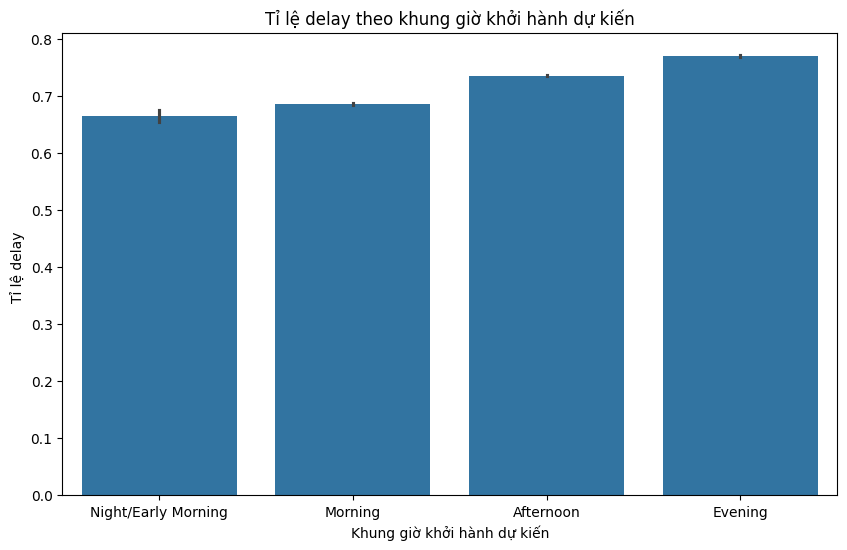

In [36]:
# 5.1.2.1 Trực quan tỉ lệ delay theo khung giờ khởi hành dự kiến 
plt.figure(figsize=(10, 6))
sns.barplot(
    x ='DepTimePeriod',
    y ='IsDelayed',
    data = df_clean,
    order=['Night/Early Morning', 'Morning', 'Afternoon', 'Evening']
)
plt.title('Tỉ lệ delay theo khung giờ khởi hành dự kiến')
plt.xlabel('Khung giờ khởi hành dự kiến')
plt.ylabel('Tỉ lệ delay ')
plt.show()

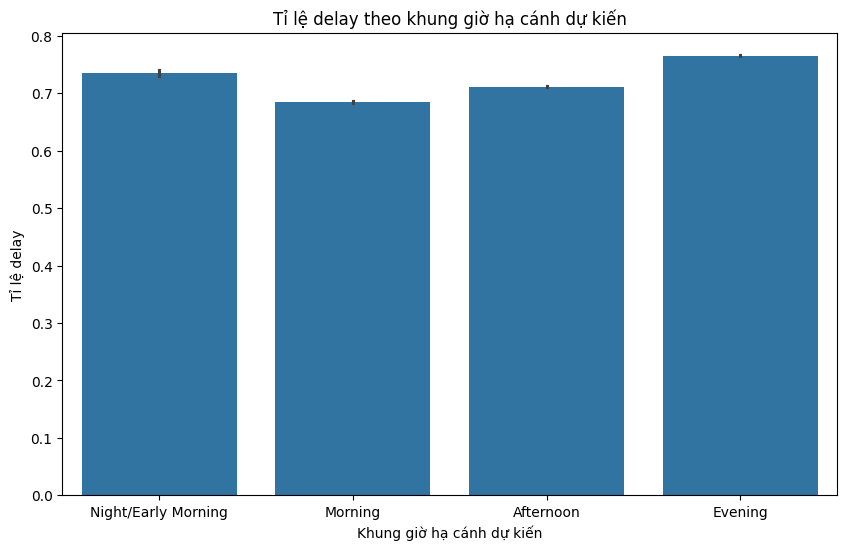

In [37]:
# 5.1.2.2 Trực quan tỉ lệ delay theo khung giờ hạ cánh dự kiến 
plt.figure(figsize=(10, 6))
sns.barplot(
    x ='ArrTimePeriod',
    y ='IsDelayed',
    data = df_clean,
    order=['Night/Early Morning', 'Morning', 'Afternoon', 'Evening']
)
plt.title('Tỉ lệ delay theo khung giờ hạ cánh dự kiến')
plt.xlabel('Khung giờ hạ cánh dự kiến')
plt.ylabel('Tỉ lệ delay')
plt.show()

=> Ta thấy khung giờ khởi hành vào buổi chiều và tối thường hay xảy ra delay. Còn với khung giờ hạ cánh dự kiến vào buổi đêm/sáng sớm hay buổi tối sẽ thường xảy ra delay.

### 5.2 Trực quan thời gian giữa tháng, ngày trong tháng, ngày trong tuần với nhãn dữ liệu 

### 5.2.1 Trực quan tháng với tỉ lệ delay trùng bình của các chuyến bay

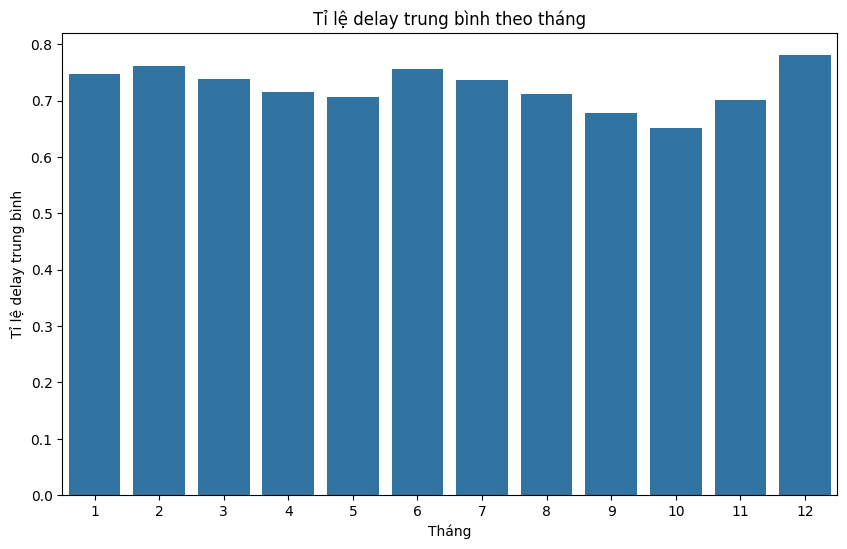

In [36]:
Delay_by_Month = df_clean.groupby('Month')['IsDelayed'].mean()

plt.figure(figsize=(10, 6))
sns.barplot(x = Delay_by_Month.index, y = Delay_by_Month.values)
plt.title("Tỉ lệ delay trung bình theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Tỉ lệ delay trung bình")
plt.show()

In [37]:
df_clean[['Month', 'IsDelayed']].corr()

,Month,IsDelayed
Month,1.000000,-0.014157
IsDelayed,-0.014157,1.000000


=> Các tháng đều cho thấy tỉ lệ delay tương quan với nhau, nhưng nhìn ma trận tương quan ta cũng thấy được Tháng nó có mối quan hệ phi tuyến với tỉ lệ delay. Cho nên ta không thể xác định được tháng cụ thể cho tỉ lệ delay 

### 5.2.2 Trực quan ngày trong tháng với tỉ lệ delay trung bình của các chuyến bay 

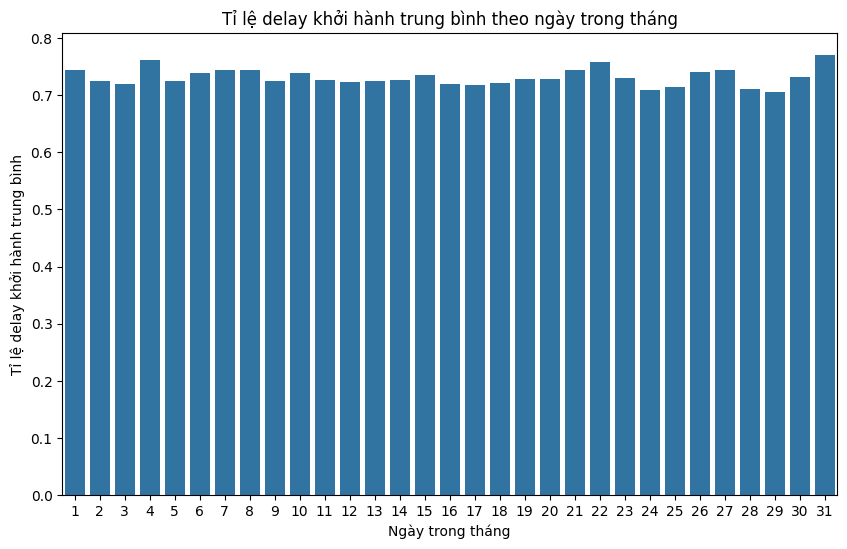

In [38]:
Delay_by_DofM = df_clean.groupby('DayofMonth')['IsDelayed'].mean()

plt.figure(figsize=(10, 6))
sns.barplot(x = Delay_by_DofM.index, y = Delay_by_DofM.values)
plt.title("Tỉ lệ delay khởi hành trung bình theo ngày trong tháng")
plt.xlabel("Ngày trong tháng")
plt.ylabel("Tỉ lệ delay khởi hành trung bình")
plt.show()

In [39]:
df_clean[['DayofMonth', 'IsDelayed']].corr()

,DayofMonth,IsDelayed
DayofMonth,1.000000,-0.004424
IsDelayed,-0.004424,1.000000


### 5.2.3 Trực quan ngày trong tuần với tỉ lệ delay trung bình của các chuyến bay 

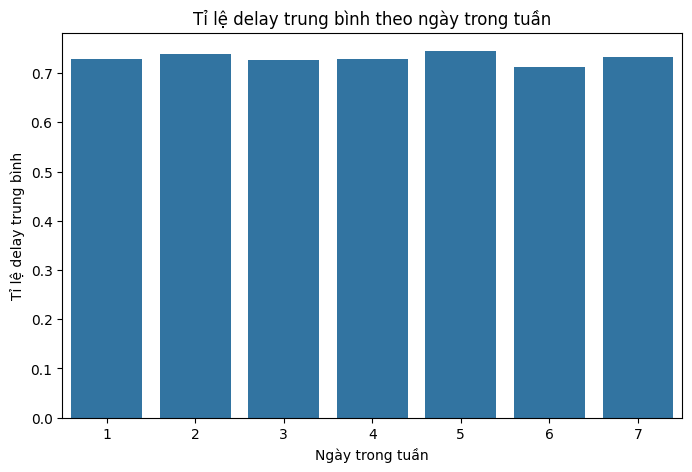

In [40]:
Delay_by_day = df_clean.groupby('DayOfWeek')['IsDelayed'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x = Delay_by_day.index, y = Delay_by_day.values)
plt.title("Tỉ lệ delay trung bình theo ngày trong tuần")
plt.xlabel("Ngày trong tuần")
plt.ylabel("Tỉ lệ delay trung bình")
plt.show()


In [41]:
df_clean[['DayOfWeek', 'IsDelayed']].corr()

,DayOfWeek,IsDelayed
DayOfWeek,1.000000,-0.001469
IsDelayed,-0.001469,1.000000


### 5.3 Trực quan giữa các hãng bay đối với tỉ lệ delay trung bình của các chuyến bay

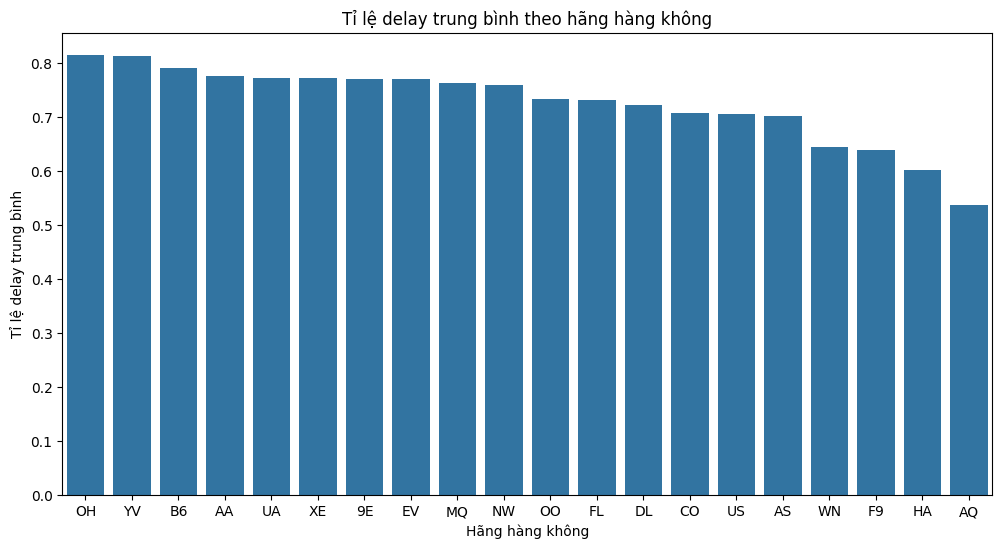

In [42]:
plt.figure(figsize=(12, 6))
carrier_delay = df_clean.groupby('UniqueCarrier')['IsDelayed'].mean().sort_values(ascending=False)
sns.barplot(x=carrier_delay.index, y=carrier_delay.values)
plt.title('Tỉ lệ delay trung bình theo hãng hàng không')
plt.xlabel('Hãng hàng không')
plt.ylabel('Tỉ lệ delay trung bình')
plt.show()

### 5.4 Trực quan giữa sân bay với tỉ lệ độ trễ trung bình cao nhất 

### 5.4.1 Top 10 sân bay đi có tỉ lệ delay trung bình cao nhất

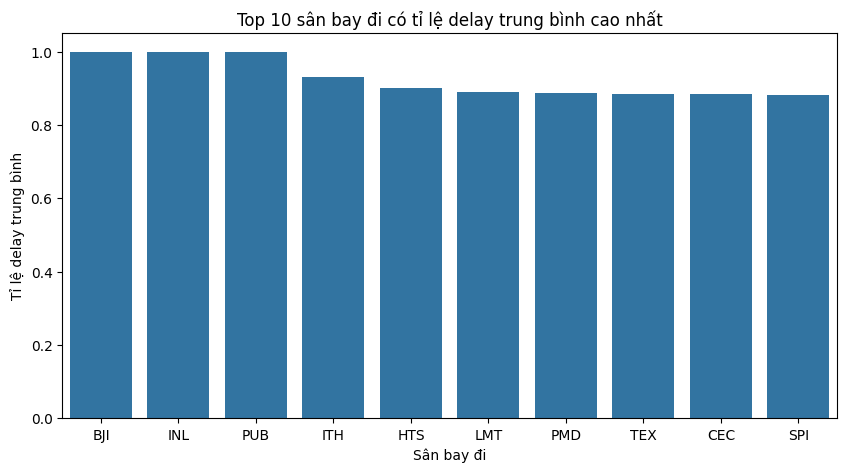

In [43]:
top_origin_delay = df_clean.groupby('Origin')['IsDelayed'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_origin_delay.index, y=top_origin_delay.values)
plt.title("Top 10 sân bay đi có tỉ lệ delay trung bình cao nhất")
plt.xlabel("Sân bay đi")
plt.ylabel("Tỉ lệ delay trung bình")
plt.show()

### 5.4.2 Top 10 sân bay đến có tỉ lệ delay trung bình cao nhất

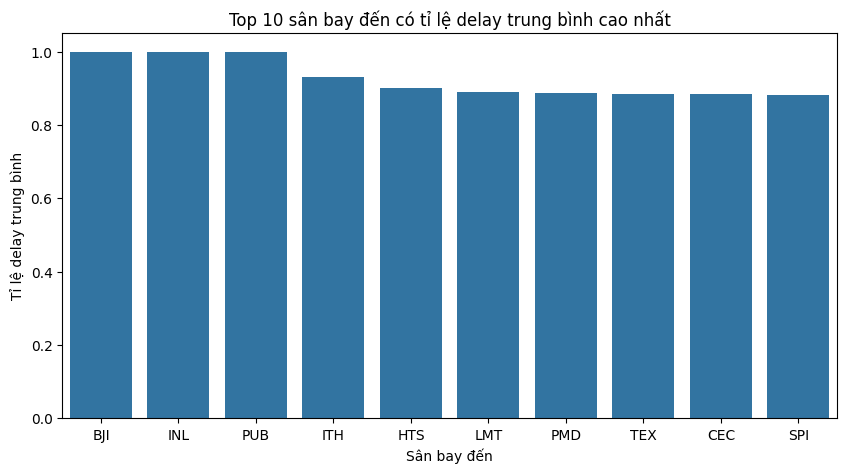

In [44]:
top_dest_delay = df_clean.groupby('Dest')['IsDelayed'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_origin_delay.index, y=top_origin_delay.values)
plt.title("Top 10 sân bay đến có tỉ lệ delay trung bình cao nhất")
plt.xlabel("Sân bay đến")
plt.ylabel("Tỉ lệ delay trung bình")
plt.show()

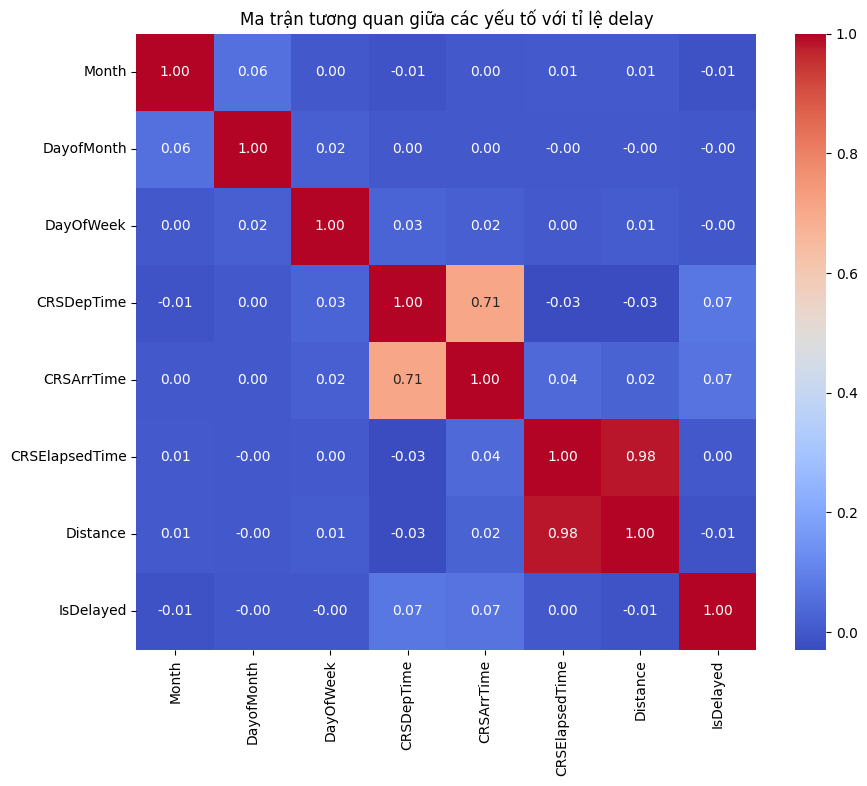

In [86]:
plt.figure(figsize=(10, 8))
corr_cols = ['Month', 'DayofMonth', 'DayOfWeek', 'CRSDepTime','CRSArrTime','CRSElapsedTime', 'Distance', 'IsDelayed']
corr_cols = [c for c in corr_cols if c in df_clean.columns]
corr_matrix = df_clean[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các yếu tố với tỉ lệ delay')
plt.show()

### 6. Chia dữ liệu và chuẩn hóa dữ liệu cần thiết chuẩn bị cho huấn luyện mô hình

### 6.1 Lấy các hàm để chia dữ liệu và chuẩn hóa từ thư viện scikit learn

In [38]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder #Chuẩn hóa dữ liệu
from sklearn.model_selection import train_test_split #Chia dữ liệu
from scipy.sparse import hstack

### 6.2 Chuẩn bị dữ liệu và chia tập train - test cho hai bài toán

In [39]:
# Chuẩn bị dữ liệu cho bài toán dự đoán delay của mỗi chuyến bay
X = df_clean.drop(['IsDelayed'], axis = 1)
y = df_clean['IsDelayed']

# Chia dữ liệu cho bài toán dự đoán delay của mỗi chuyến bay
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [40]:
print(X.shape)
print(y.shape)

(1928363, 12)
(1928363,)


In [62]:
print(X_train.shape)
print(y_train.shape)

(1542690, 12)
(1542690,)


In [63]:
print(X_test.shape)
print(y_test.shape)

(385673, 12)
(385673,)


In [41]:
df_clean.isna().sum()

Month             0
DayofMonth        0
DayOfWeek         0
CRSDepTime        0
CRSArrTime        0
UniqueCarrier     0
CRSElapsedTime    0
Origin            0
Dest              0
Distance          0
IsDelayed         0
DepTimePeriod     0
ArrTimePeriod     0
dtype: int64

In [50]:
df_clean.duplicated().sum()

np.int64(0)

### 6.3 Chuẩn hóa dữ liệu chuẩn bị huấn luyện mô hình

*Lưu ý: Với dữ liệu Numerical Data sẽ có một số mô hình không cần chuẩn hóa nhưng vẫn thể train tốt như: Decision Tree hay Xgboost, trong khi đó mô hình như Logistic Regression lại cực nhạy cảm với dữ liệu Numerical bị lệch nên với model nào cần ta mới scale. Còn với categorical data thì hầu như tất cả các mô hình đều không hiểu dạng chữ nên ta cần phải encode chung.

In [48]:
df_clean.columns

Index(['Month', 'DayofMonth', 'DayOfWeek', 'CRSDepTime', 'CRSArrTime',
       'UniqueCarrier', 'CRSElapsedTime', 'Origin', 'Dest', 'Distance',
       'IsDelayed', 'DepTimePeriod', 'ArrTimePeriod'],
      dtype='str')

In [42]:
# Numeric features
numeric_features = [ 'Month', 'DayofMonth', 'DayOfWeek', 'CRSDepTime', 
                     'CRSArrTime','CRSElapsedTime', 'Distance']

# Categorical features
categorical_features = ['UniqueCarrier', 'Origin', 'Dest', 'DepTimePeriod', 'ArrTimePeriod']

In [43]:
scaler = StandardScaler() 
encoder = OneHotEncoder(handle_unknown='ignore')

In [44]:
# Dữ liệu numeric của bài toán 
X_train_nu = X_train[numeric_features]
X_test_nu = X_test[numeric_features]

# Encode dữ liệu cho bài toán 
X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

### 7. Huấn luyện mô hình cho bài toán và đưa ra đánh giá 

Các mô hình được sử dụng trong bài toán gồm: Logistic Regression, Decision Tree và Xgboost

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

Vì đây là bài toán phân loại ta sẽ sử dụng metric đánh giá của bài toán phân loại gồm: Accuracy, Recall, Precision, F1-Score

In [46]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score

### Huấn luyện cho mô hình Logistic Regression

In [47]:
# Chuẩn hóa dữ liệu numeric và lấy bộ dữ liệu chính
X_train_scale = scaler.fit_transform(X_train_nu)
X_test_scale = scaler.transform(X_test_nu)

X_final_train = hstack([X_train_scale , X_train_cat])
X_final_test = hstack([X_test_scale , X_test_cat])

In [48]:
# Huấn luyện cho mô hình Logistic Regression
LReg_model = LogisticRegression(max_iter = 1000, class_weight = 'balanced', C = 0.01)
LReg_model.fit(X_final_train, y_train)
y_prob_LR = LReg_model.predict_proba(X_final_test)[:,1]
# y_pred_LR = (y_prob >= 0.5).astype(int)
y_pred_LG = LReg_model.predict(X_final_test)
print("Bảng đánh giá độ đo của mô hình Logistic Regression:")
print(classification_report(y_test, y_pred_LG))
# print("Bảng đánh giá độ đo của mô hình Logistic Regression:")
# print(classification_report(y_test, y_pred_LR))

Bảng đánh giá độ đo của mô hình Logistic Regression:
              precision    recall  f1-score   support

           0       0.34      0.59      0.43    103843
           1       0.79      0.57      0.66    281830

    accuracy                           0.57    385673
   macro avg       0.56      0.58      0.54    385673
weighted avg       0.67      0.57      0.60    385673



In [49]:
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_LR)
auc_lr = roc_auc_score(y_test, y_prob_LR)

print("AUC Logistic Regression:", auc_lr)

AUC Logistic Regression: 0.6141923647357688


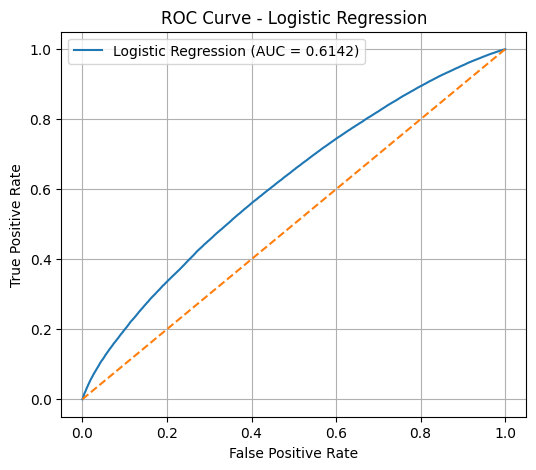

In [50]:
plt.figure(figsize=(6,5))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()

plt.show()

### Huấn luyện cho mô hình Decision Tree

In [60]:
X_final_train = hstack([X_train_nu , X_train_cat])
X_final_test = hstack([X_test_nu, X_test_cat])

In [51]:
DT_model = DecisionTreeClassifier(
    class_weight = 'balanced',
    max_depth = 10,
    min_samples_split = 10,
    min_samples_leaf = 20,
    random_state = 42)
DT_model.fit(X_final_train,y_train)
y_prob = DT_model.predict_proba(X_final_test)[:,1]
y_pred_DT = (y_prob >= 0.5).astype(int)
print("Bảng đánh giá độ đo của mô hình Decision Tree:")
print(classification_report(y_test, y_pred_DT))

Bảng đánh giá độ đo của mô hình Decision Tree:
              precision    recall  f1-score   support

           0       0.34      0.51      0.41    103843
           1       0.78      0.64      0.70    281830

    accuracy                           0.61    385673
   macro avg       0.56      0.58      0.56    385673
weighted avg       0.66      0.61      0.63    385673



In [52]:
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob)
auc_dt = roc_auc_score(y_test, y_prob)

print("AUC:", auc_dt)

AUC: 0.6148984930475139


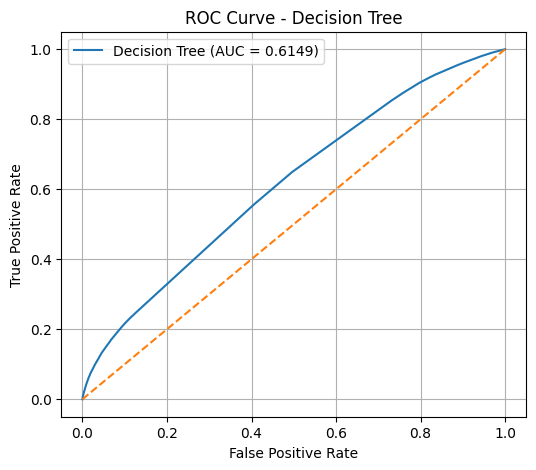

In [53]:
plt.figure(figsize=(6,5))

plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # đường baseline random

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.grid()

plt.show()

### Huấn luyện cho mô hình Xgboost

In [54]:
from xgboost import XGBClassifier
XGB_model = XGBClassifier(n_estimators=400,
    learning_rate = 0.03,
    max_depth = 5,
    min_child_weight = 5,
    subsample = 0.8,
    colsample_bytree = 0.8,
    gamma = 1,
    random_state = 42,
    eval_metric = 'logloss')
XGB_model.fit(X_final_train, y_train)
# y_pred_XGB = XGB_model.predict(X_final_test)
# print(classification_report(y_test, y_pred_XGB))
y_prob_xgb = XGB_model.predict_proba(X_final_test)[:,1]

y_pred = (y_prob_xgb >= 0.7).astype(int)
print("Bảng đánh giá độ đo của mô hình Xgboost:")
print(classification_report(y_test, y_pred))

Bảng đánh giá độ đo của mô hình Xgboost:
              precision    recall  f1-score   support

           0       0.39      0.46      0.42    103843
           1       0.79      0.74      0.76    281830

    accuracy                           0.66    385673
   macro avg       0.59      0.60      0.59    385673
weighted avg       0.68      0.66      0.67    385673



In [55]:
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("AUC XGBoost:", auc_xgb)

AUC XGBoost: 0.6493609276448497


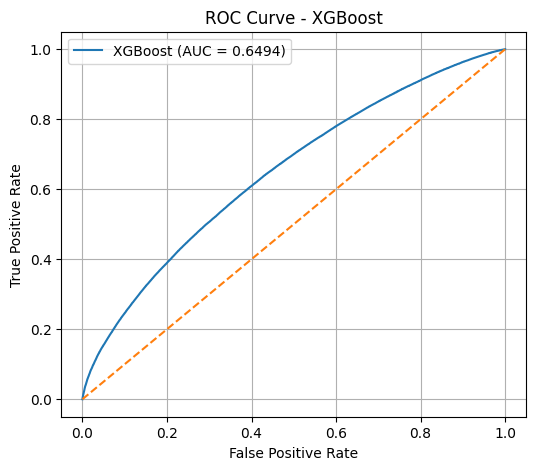

In [56]:
plt.figure(figsize=(6,5))

plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid()

plt.show()

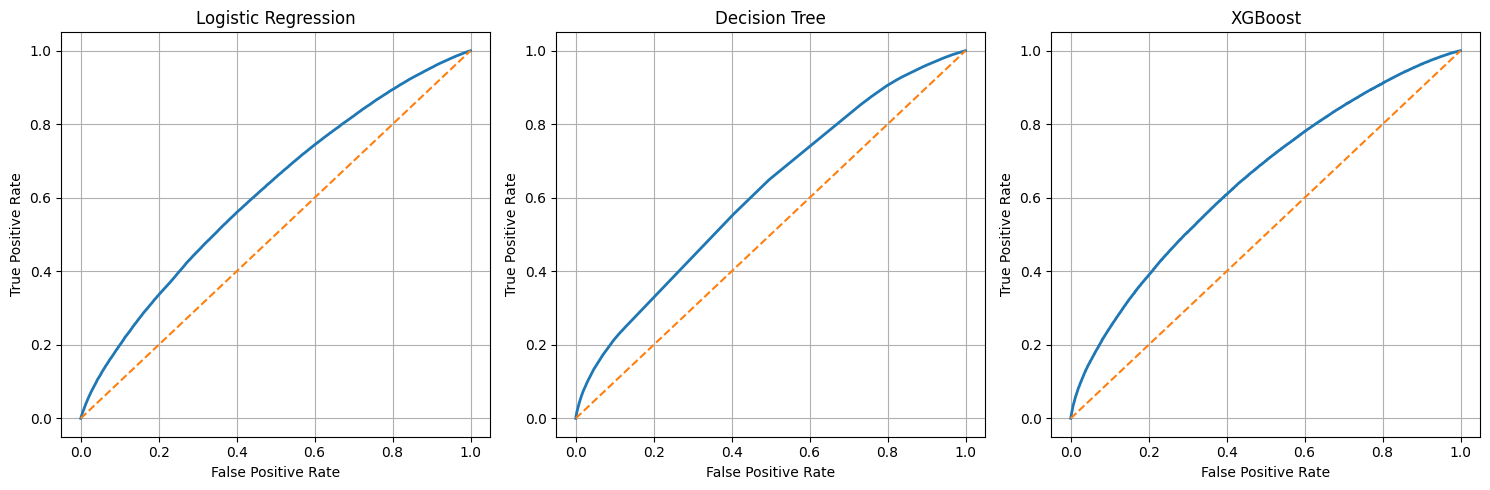

In [60]:
curves = [
    (fpr_lr, tpr_lr, "Logistic Regression"),
    (fpr_dt, tpr_dt, "Decision Tree"),
    (fpr_xgb, tpr_xgb, "XGBoost")
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for ax, (fpr, rpr, title) in zip(axes, curves):
    ax.plot(fpr, rpr, linewidth=2)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.grid(True)
    ax.plot([0, 1], [0, 1], linestyle='--')

plt.tight_layout()
plt.show()

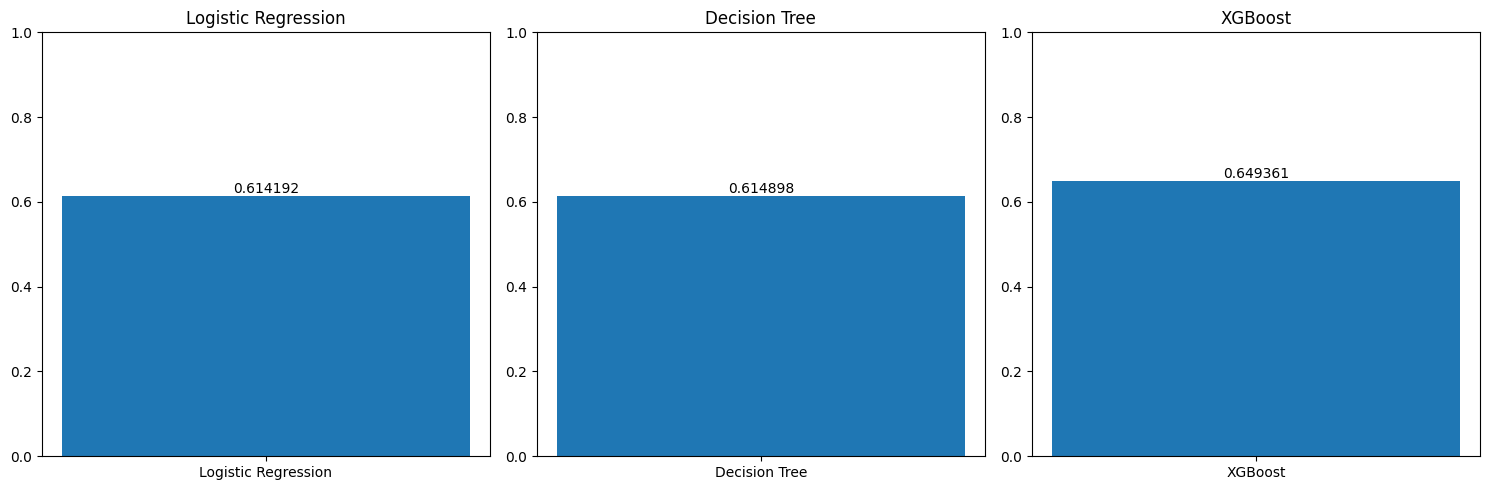

In [61]:
curves = [
    (auc_lr, "Logistic Regression"),
    (auc_dt, "Decision Tree"),
    (auc_xgb, "XGBoost")
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for ax, (auc, title) in zip(axes, curves):
    bars = ax.bar(title, auc)
    ax.bar_label(bars)
    ax.set_title(title)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 8. Load model chuẩn bị cho demo web

In [ ]:
import joblib

# save model
joblib.dump(LReg_model, '../backend/models/logistic.pkl')

joblib.dump(DT_model, '../backend/models/decision_tree.pkl')

joblib.dump(XGB_model, '../backend/models/xgboost.pkl')

# save preprocessing
joblib.dump(scaler, '../backend/models/scaler.pkl')

joblib.dump(encoder, '../backend/models/encoder.pkl')

# route distance
route_distance = (
    df_clean.groupby(['Origin', 'Dest'])['Distance']
    .mean()
    .to_dict()
)

joblib.dump(route_distance,'../backend/models/route_distance.pkl')

print('Saved successfully')

Saved successfully


In [ ]:
# Save Origin, Dest and Airline
origin_list = sorted(
    df_clean['Origin'].unique().tolist()
)

# =========================
# DEST LIST
# =========================

dest_list = sorted(
    df_clean['Dest'].unique().tolist()
)

# =========================
# AIRLINE LIST
# =========================

airline_list = sorted(
    df_clean['UniqueCarrier'].unique().tolist()
)

# =========================
# SAVE
# =========================

joblib.dump(
    origin_list,
    '../backend/models/origin_list.pkl'
)

joblib.dump(
    dest_list,
    '../backend/models/dest_list.pkl'
)

joblib.dump(
    airline_list,
    '../backend/models/airline_list.pkl'
)

print('Saved successfully')

Lists saved successfully


In [ ]:
# Lấy thời gian hoàn thành chuyến bay theo origin tới dest 
route_elapsed = (
    df_clean.groupby(['Origin', 'Dest'])['CRSElapsedTime']
    .mean()
    .to_dict()
)

joblib.dump(route_elapsed,'../backend/models/route_elapsed.pkl')

print('Saved successfully')

['../backend/models/route_elapsed.pkl']

In [67]:
# Save dữ liệu mới để lấy tỉ lệ delay trung bình theo hãng bay, biểu diễn cho web
airline_stats = (
    df_clean
    .groupby('UniqueCarrier')
    .agg({
        'IsDelayed': 'mean',
        'Distance': 'mean',
        'UniqueCarrier': 'count'
    })
)

airline_stats.columns = [
    'DelayRate',
    'AvgDistance',
    'TotalFlights'
]

airline_stats['DelayRate'] *= 100

def get_score(rate):

    if rate < 60:
        return 'Excellent'

    elif rate < 68:
        return 'Good'

    elif rate < 75:
        return 'Average'

    else:
        return 'Poor'


In [68]:
airline_stats['Reliability'] = (
    airline_stats['DelayRate']
    .apply(get_score)
)

joblib.dump(airline_stats,'../backend/models/airline_stats.pkl')
print('Saved successfully')

Saved successfully
